In [1]:
import pandas as pd
import optuna
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import shap

c:\Users\local_user\anaconda3\envs\EnergyPrices\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
all_data_set = pd.read_csv("processed_data\Processed_data.csv", index_col=0)
all_data_set
# Feature lags in 15-min steps
STATE_LAGS = [1, 4, 8, 24, 96, 192, 672]   # 15m, 1h, 2h, 6h, 1d, 2d, 1w
STATE_ROLL_WINS = [24, 96, 672]            # rolling windows on past y (6h, 1d, 1w)

# Feature columns
STATE_FEATURES = (
    ["last_y"]
    + [f"lag_{L}_t0" for L in STATE_LAGS]
    + ["ramp_1h_t0", "ramp_6h_t0", "ramp_1d_t0"]
    + [f"roll_mean_{w}_t0" for w in STATE_ROLL_WINS]
    + [f"roll_std_{w}_t0" for w in STATE_ROLL_WINS]
)

HORIZON_FEATURES = [
    "h", "q_in_hour_target", "qod_target", "hod_target", "dow_target", "month_target", "is_weekend_target",
    "load_fc_target", "load_ramp_1h_target", "load_ramp_6h_target",
    "load_day_mean", "load_day_max", "load_day_min",
]

FEATURE_COLS = STATE_FEATURES + HORIZON_FEATURES

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\local_user\AppData\Local\Temp\ipykernel_17316\2176525123.py:1: SyntaxWarning: invalid escape sequence '\P'
  all_data_set = pd.read_csv("processed_data\Processed_data.csv", index_col=0)


In [4]:
def get_best_params(
    ds: pd.DataFrame,   
    train_days_pool: np.ndarray,
    val_days: np.ndarray,
    n_trials: int
):
    
    ds_train_pool = ds[ds["day"].isin(train_days_pool)].copy()
    ds_val_pool = ds[ds["day"].isin(val_days)].copy()


    def objective(trial: optuna.trial.Trial):

        preds = []
        trues = []

        synth_weight = trial.suggest_float("synth_weight", 0.05, 0.8, log=True)
        retrain_every = trial.suggest_int("retrain_every", 1, 10)

        # --- All other single-stage models ---
        for i, D in enumerate(val_days):
            train_slice = ds_train_pool[ds_train_pool["day"] < D].copy()
            day_rows = ds_val_pool[ds_val_pool["day"] == D].copy()
            if train_slice.empty or day_rows.empty:
                continue

            w = np.where(train_slice["is_synthetic"].values == 1, synth_weight, 1.0).astype(float)

            if  i % retrain_every == 0:
                # Need a fresh model each retrain for sklearn pipelines

                model = xgb.XGBRegressor(
                    # objective
                    objective="reg:squarederror",
                    eval_metric="mae",

                    # core boosting params (roughly analogous to LGB)
                    n_estimators=trial.suggest_int("xgb_n_estimators", 400, 2500),
                    learning_rate=trial.suggest_float("xgb_lr", 0.01, 0.08, log=True),

                    # tree shape / complexity
                    max_depth=trial.suggest_int("xgb_max_depth", 3, 12),
                    min_child_weight=trial.suggest_float("xgb_min_child_weight", 1e-2, 50.0, log=True),

                    # sampling (same names as LGB for these)
                    subsample=trial.suggest_float("xgb_subsample", 0.6, 1.0),
                    colsample_bytree=trial.suggest_float("xgb_colsample", 0.6, 1.0),

                    # regularization (same names as LGB)
                    reg_alpha=trial.suggest_float("xgb_reg_alpha", 1e-8, 10.0, log=True),
                    reg_lambda=trial.suggest_float("xgb_reg_lambda", 1e-8, 10.0, log=True),

                    # optional knobs often worth tuning
                    gamma=trial.suggest_float("xgb_gamma", 0.0, 10.0),
                    max_delta_step=trial.suggest_int("xgb_max_delta_step", 0, 10),

                    random_state=42,
                    n_jobs=-1,

                    tree_method="hist",
                    verbosity=0,
                )


                model.fit(train_slice[FEATURE_COLS], train_slice["y_target"], sample_weight=w)
                fitted = model

            y_hat = fitted.predict(day_rows[FEATURE_COLS])
            preds.append(y_hat)
            trues.append(day_rows["y_target"].values)

        if not preds:
            return float("inf")
        
        y_true = np.concatenate(trues)
        y_hat = np.concatenate(preds)

        mae = mean_absolute_error(y_true, y_hat)
        return mae
    
    study = optuna.create_study(direction="minimize", study_name="HUPX_test")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print("Best overall value:", study.best_value)
    print("Best overall params:", study.best_params)
    return study


In [ ]:
FINAL_TEST_DAYS = 30
real_rows = all_data_set[(all_data_set["is_observed"] == 1) & (all_data_set["is_synthetic"] == 0)]
real_days = np.array(sorted(real_rows["day"].unique()))

all_days = np.array(sorted(all_data_set["day"].unique()))
final_test_days = all_days[-FINAL_TEST_DAYS:]
tune_days = all_days[:-FINAL_TEST_DAYS]

# Use the last part of tune_days as Optuna validation window (e.g., 21 days)
OPTUNA_VAL_DAYS = 21
optuna_val_days = tune_days[-OPTUNA_VAL_DAYS:]
optuna_train_days_pool = tune_days[:-OPTUNA_VAL_DAYS]
print("Optuna train pool:", optuna_train_days_pool[0], "→", optuna_train_days_pool[-1], len(optuna_train_days_pool))
print("Optuna val days  :", optuna_val_days[0], "→", optuna_val_days[-1], len(optuna_val_days))
print("Final test days  :", final_test_days[0], "→", final_test_days[-1], len(final_test_days))



study = get_best_params(
    ds=all_data_set,
    train_days_pool=optuna_train_days_pool,
    val_days=optuna_val_days,
    n_trials=300
)

[I 2026-03-04 21:18:37,381] A new study created in memory with name: HUPX_test


Optuna train pool: 2024-01-16 00:00:00+01:00 → 2025-12-31 00:00:00+01:00 716
Optuna val days  : 2026-01-01 00:00:00+01:00 → 2026-01-21 00:00:00+01:00 21
Final test days  : 2026-01-22 00:00:00+01:00 → 2026-02-24 00:00:00+01:00 30


Best trial: 0. Best value: 30.7525:  10%|█         | 1/10 [01:08<10:15, 68.43s/it]

[I 2026-03-04 21:19:45,811] Trial 0 finished with value: 30.752491624090407 and parameters: {'synth_weight': 0.767711660690451, 'retrain_every': 3, 'xgb_n_estimators': 2059, 'xgb_lr': 0.047749018225067795, 'xgb_max_depth': 5, 'xgb_min_child_weight': 7.831877679402369, 'xgb_subsample': 0.9482650022944226, 'xgb_colsample': 0.9542220852417675, 'xgb_reg_alpha': 0.1361386531076651, 'xgb_reg_lambda': 0.00031203718570824726, 'xgb_gamma': 4.959476245914151, 'xgb_max_delta_step': 10}. Best is trial 0 with value: 30.752491624090407.


Best trial: 1. Best value: 27.2821:  20%|██        | 2/10 [07:51<35:21, 265.13s/it]

...

[I 2026-03-04 21:32:16,646] Trial 7 finished with value: 32.17649445692698 and parameters: {'synth_weight': 0.1299802714997405, 'retrain_every': 6, 'xgb_n_estimators': 1823, 'xgb_lr': 0.015301809442961653, 'xgb_max_depth': 3, 'xgb_min_child_weight': 0.17067821061190652, 'xgb_subsample': 0.7026742690765785, 'xgb_colsample': 0.9936547507445421, 'xgb_reg_alpha': 0.0005847813917972276, 'xgb_reg_lambda': 0.40937052753750275, 'xgb_gamma': 3.2373332180441072, 'xgb_max_delta_step': 9}. Best is trial 4 with value: 24.842148667819913.


Best trial: 4. Best value: 24.8421:  90%|█████████ | 9/10 [14:14<01:01, 61.25s/it]

[I 2026-03-04 21:32:52,304] Trial 8 finished with value: 26.35150240360744 and parameters: {'synth_weight': 0.5222289718489599, 'retrain_every': 5, 'xgb_n_estimators': 1579, 'xgb_lr': 0.016479605624944008, 'xgb_max_depth': 5, 'xgb_min_child_weight': 0.32542548494362855, 'xgb_subsample': 0.8716762693039272, 'xgb_colsample': 0.6592545386581303, 'xgb_reg_alpha': 7.69371452051725e-06, 'xgb_reg_lambda': 0.3037051077139579, 'xgb_gamma': 9.641631554305945, 'xgb_max_delta_step': 4}. Best is trial 4 with value: 24.842148667819913.


Best trial: 4. Best value: 24.8421: 100%|██████████| 10/10 [16:02<00:00, 96.21s/it]

[I 2026-03-04 21:34:39,435] Trial 9 finished with value: 25.180829980486912 and parameters: {'synth_weight': 0.05081182987647658, 'retrain_every': 4, 'xgb_n_estimators': 1731, 'xgb_lr': 0.019555949866205357, 'xgb_max_depth': 10, 'xgb_min_child_weight': 3.6114488353692247, 'xgb_subsample': 0.6454882554332115, 'xgb_colsample': 0.9399228448070451, 'xgb_reg_alpha': 0.012742832680460732, 'xgb_reg_lambda': 3.262735510166835e-08, 'xgb_gamma': 6.366485965716526, 'xgb_max_delta_step': 6}. Best is trial 4 with value: 24.842148667819913.
Best overall value: 24.842148667819913
Best overall params: {'synth_weight': 0.08895427188596637, 'retrain_every': 8, 'xgb_n_estimators': 1270, 'xgb_lr': 0.023402419995712936, 'xgb_max_depth': 11, 'xgb_min_child_weight': 0.143489594777025, 'xgb_subsample': 0.9670413545872614, 'xgb_colsample': 0.680404598421343, 'xgb_reg_alpha': 1.6682806691388228, 'xgb_reg_lambda': 0.0012624211995078828, 'xgb_gamma': 7.410296072328285, 'xgb_max_delta_step': 6}


In [6]:
def walk_forward_predict_test(
    ds,
    best_params: dict,
    train_days_pool: np.ndarray,   # days you allow for training (e.g., tune_days)
    test_days: np.ndarray,         # final_test_days
    feature_cols,
    target_col="y_target",
    day_col="day",
    synth_col="is_synthetic",
):
    test_days = np.sort(np.array(test_days))

    ds_train_pool = ds[ds[day_col].isin(train_days_pool)].copy()
    ds_test_pool  = ds[ds[day_col].isin(test_days)].copy()

    synth_weight = best_params["synth_weight"]

    # Build LGB params from Optuna best params (drop non-LGB keys)
    xgb_params = {
        "objective": "reg:squarederror",              # training loss (can be reg:absoluteerror too)
        "n_estimators": best_params["xgb_n_estimators"],
        "learning_rate": best_params["xgb_lr"],
        "max_depth": best_params["xgb_max_depth"],
        "min_child_weight": best_params["xgb_min_child_weight"],
        "subsample": best_params["xgb_subsample"],
        "colsample_bytree": best_params["xgb_colsample"],
        "reg_alpha": best_params["xgb_reg_alpha"],
        "reg_lambda": best_params["xgb_reg_lambda"],
        "gamma": best_params.get("xgb_gamma", 0.0),
        "max_delta_step": best_params.get("xgb_max_delta_step", 0),
        "random_state": 42,
        "n_jobs": -1,
        "tree_method": "hist",                         # use "gpu_hist" if you have CUDA
        "verbosity": 0,
        # Optional: align evaluation metric with your reporting metric
        "eval_metric": "mae",
    }

    preds = []
    trues = []
    day_index = []
    row_index = []

    fitted = None

    retrain_every = int(best_params.get("retrain_every", 1))

    for i, D in enumerate(test_days):
        train_slice = ds_train_pool[ds_train_pool[day_col] < D].copy()
        day_rows = ds_test_pool[ds_test_pool[day_col] == D].copy()
        if train_slice.empty or day_rows.empty:
            continue

        # retrain schedule (same idea as your objective)
        if (i % retrain_every == 0) or (fitted is None):
            w = np.where(train_slice[synth_col].values == 1, synth_weight, 1.0).astype(float)

            model = xgb.XGBRegressor(**xgb_params)
            model.fit(train_slice[feature_cols], train_slice[target_col], sample_weight=w)
            fitted = model

        y_hat = fitted.predict(day_rows[feature_cols])
        y_true = day_rows[target_col].values

        preds.append(y_hat)
        trues.append(y_true)
        day_index.append(np.full(len(day_rows), D))
        row_index.append(day_rows.index.values)

    if not preds:
        raise RuntimeError("No predictions were made on test_days. Check day filters / pools.")

    y_pred = np.concatenate(preds)
    y_true = np.concatenate(trues)
    days_out = np.concatenate(day_index)
    rows_out = np.concatenate(row_index)

    mae = mean_absolute_error(y_true, y_pred)

    return {
        "y_pred": y_pred,
        "y_true": y_true,
        "days": days_out,
        "row_index": rows_out,
        "mae": mae,
        "last_model": fitted,  # the last fitted model (trained for last retrain point)
        "lgb_params": xgb_params,
        "synth_weight": synth_weight,
    }

In [7]:
best_params = study.best_params

test_res = walk_forward_predict_test(
    ds=all_data_set,
    best_params=best_params,
    train_days_pool=tune_days,        # important: allow training on ALL tune_days
    test_days=final_test_days,
    feature_cols=FEATURE_COLS,
)

print("Final test MAE:", test_res["mae"])

Final test MAE: 19.682942960951063


In [8]:
def fit_final_model_before_test(
    ds,
    best_params: dict,
    train_days_pool: np.ndarray,
    first_test_day,
    feature_cols,
    target_col="y_target",
    day_col="day",
    synth_col="is_synthetic",
):
    ds_train_pool = ds[ds[day_col].isin(train_days_pool)].copy()
    train_slice = ds_train_pool[ds_train_pool[day_col] < first_test_day].copy()
    if train_slice.empty:
        raise RuntimeError("Training slice is empty before first_test_day.")

    synth_weight = best_params["synth_weight"]
    w = np.where(train_slice[synth_col].values == 1, synth_weight, 1.0).astype(float)

    xgb_params = {
        "objective": "reg:squarederror",              # training loss (can be reg:absoluteerror too)
        "n_estimators": best_params["xgb_n_estimators"],
        "learning_rate": best_params["xgb_lr"],
        "max_depth": best_params["xgb_max_depth"],
        "min_child_weight": best_params["xgb_min_child_weight"],
        "subsample": best_params["xgb_subsample"],
        "colsample_bytree": best_params["xgb_colsample"],
        "reg_alpha": best_params["xgb_reg_alpha"],
        "reg_lambda": best_params["xgb_reg_lambda"],
        "gamma": best_params.get("xgb_gamma", 0.0),
        "max_delta_step": best_params.get("xgb_max_delta_step", 0),
        "random_state": 42,
        "n_jobs": -1,
        "tree_method": "hist",                         # use "gpu_hist" if you have CUDA
        "verbosity": 0,
        # Optional: align evaluation metric with your reporting metric
        "eval_metric": "mae",
    }

    model = xgb.XGBRegressor(**xgb_params)
    model.fit(train_slice[feature_cols], train_slice[target_col], sample_weight=w)
    return model

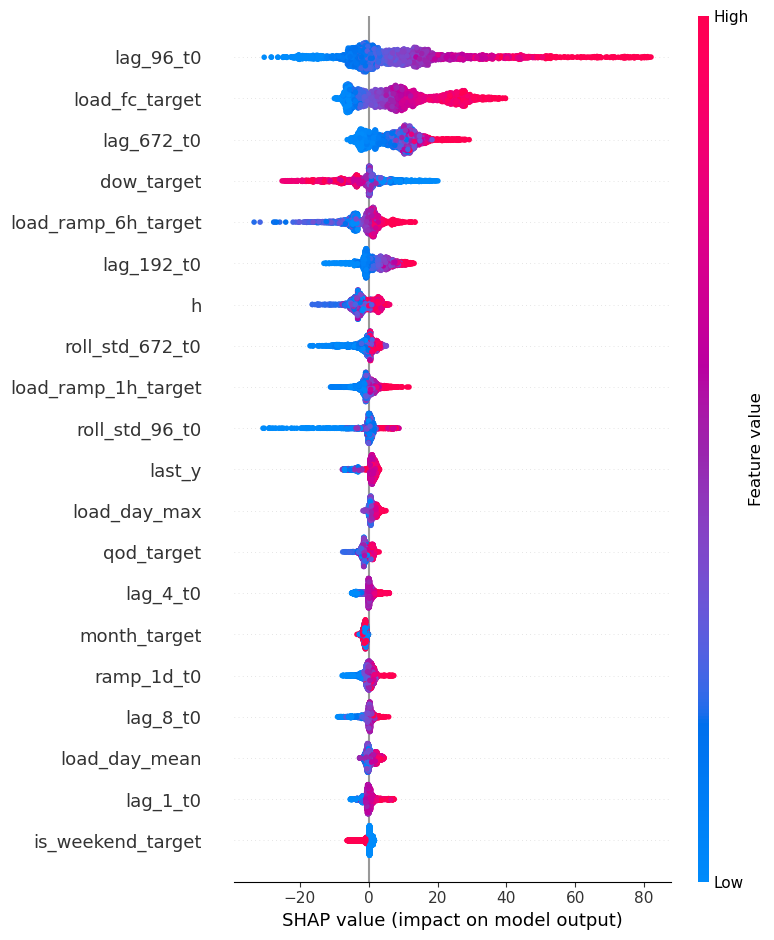

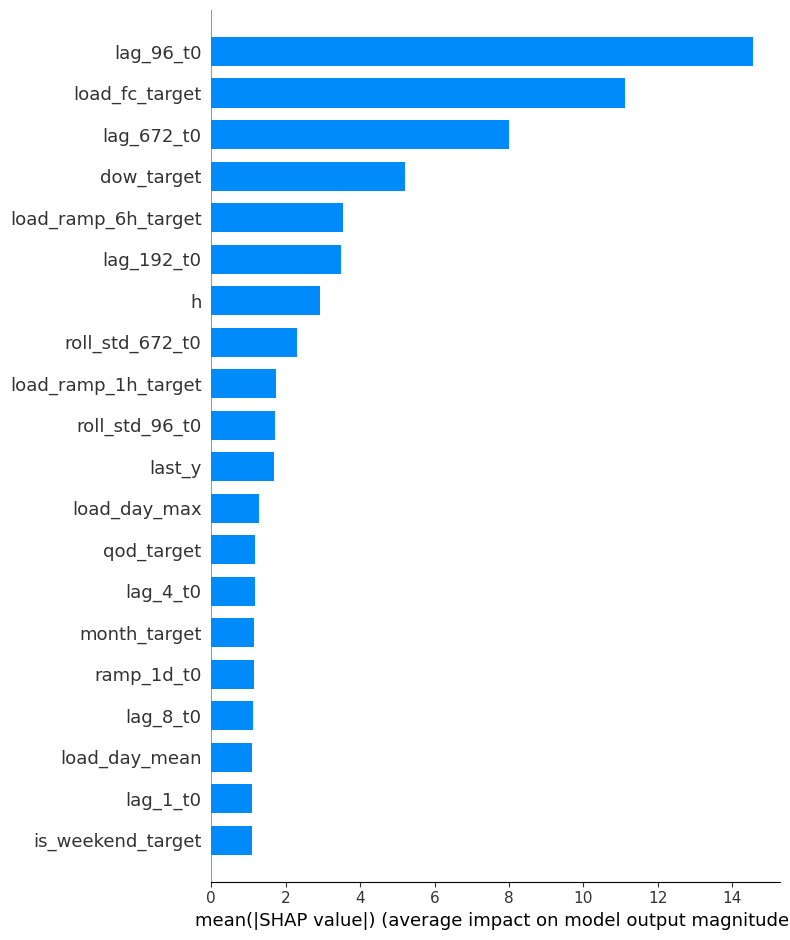

In [9]:
first_test_day = final_test_days[0]

final_model = fit_final_model_before_test(
    ds=all_data_set,
    best_params=study.best_params,
    train_days_pool=tune_days,
    first_test_day=first_test_day,
    feature_cols=FEATURE_COLS,
)

test_df = all_data_set[all_data_set["day"].isin(final_test_days)].copy()
X_test = test_df[FEATURE_COLS]


explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# Summary plot (beeswarm)
shap.summary_plot(shap_values, X_test)

# Bar plot (global importance)
shap.summary_plot(shap_values, X_test, plot_type="bar")